# MNIST digits recognition
## Feedforward network with 2 hidden layers

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eduenez/MathAIspring2026UTSA/blob/main/code/intro_feedforward_mnist.ipynb)

Uses [Keras](https://keras.io/) with [JAX](https://github.com/jax-ml/jax) as NN engine.

In [18]:
# Install Jax running on Google/Colab Tensor Processing Units
!pip install "jax[tpu]"

# Install Keras
!pip install keras-cv
!pip install keras-hub
!pip install keras

In [19]:
# Import installed software and put things in place
import os
os.environ["KERAS_BACKEND"] = "jax"
import matplotlib.pyplot as plt
import numpy as np
from keras import layers
from keras import ops
import keras
# print(keras.__version__)
# print(keras.backend.backend())

# Model `model` below is a feedforward network

- Input layer of dimension `784` (each MNIST character is encoded as a 28-by-28 image having `28*28 = 784` pixels when “flattened”).
- Dense (“fully connected”) hidden layer 1 of dimension `64`.
- Dense (“fully connected”) hidden layer 2 of dimension `64`.
- Dense (“fully connected”) output layer of dimension `10`.

The `model` is then created as a Keras model object.
It will process `784`-dimensional inputs and generate `10`-dimensional outputs.

- Each of the 64 dimensions of the 1st layer has 784 linear cofficients plus 1 bias = 785 parameters, for a total of 64*785 = `50,240` parameters.
- Each of the 64 dimensions of the 1st layer has 64 linear cofficients plus 1 bias = 65 parameters, for a total of 64*65 = `4,160` parameters.
- Each of the 10 dimensions of the 1st layer has 64 linear cofficients plus 1 bias = 65 parameters, for a total of 10*65 = `650` parameters.

Therefore, `model` has `50,240 + 4,160 + 650 = 55,050` total parameters.

**Note:** The MNIST data set has *not* yet been loaded at all!
Absolutely *no* data proper has been used at this point.


In [20]:
dim_hl_1 = 64 # @param {type: "integer"}
dim_hl_2 = 64 # @param {type: "integer"}

inputs = keras.Input(shape=(784,))  # Input layer shape for flatened MNIST images
hidden1 = layers.Dense(dim_hl_1, activation="relu")(inputs)  # First hidden layer
hidden2 = layers.Dense(dim_hl_2, activation="relu")(hidden1)  # Second hidden layer
# Output layer must have dimension 10 = number of categories.
outputs = layers.Dense(10)(hidden2)  # No ReLu here b/c output is "logits".
model = keras.Model(inputs=inputs, outputs=outputs, name="mnist_model")
model.summary()


Model: "mnist_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_33 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_99 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_100 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_101 (Dense)               │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,050 (215.04 KB)

 Trainable params: 55,050 (215.04 KB)

 Non-trainable params: 0 (0.00 B)

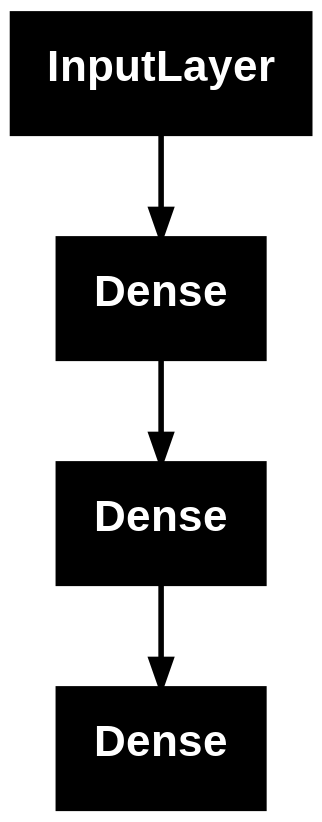

In [21]:
keras.utils.plot_model(model, "feedforward_model.png")

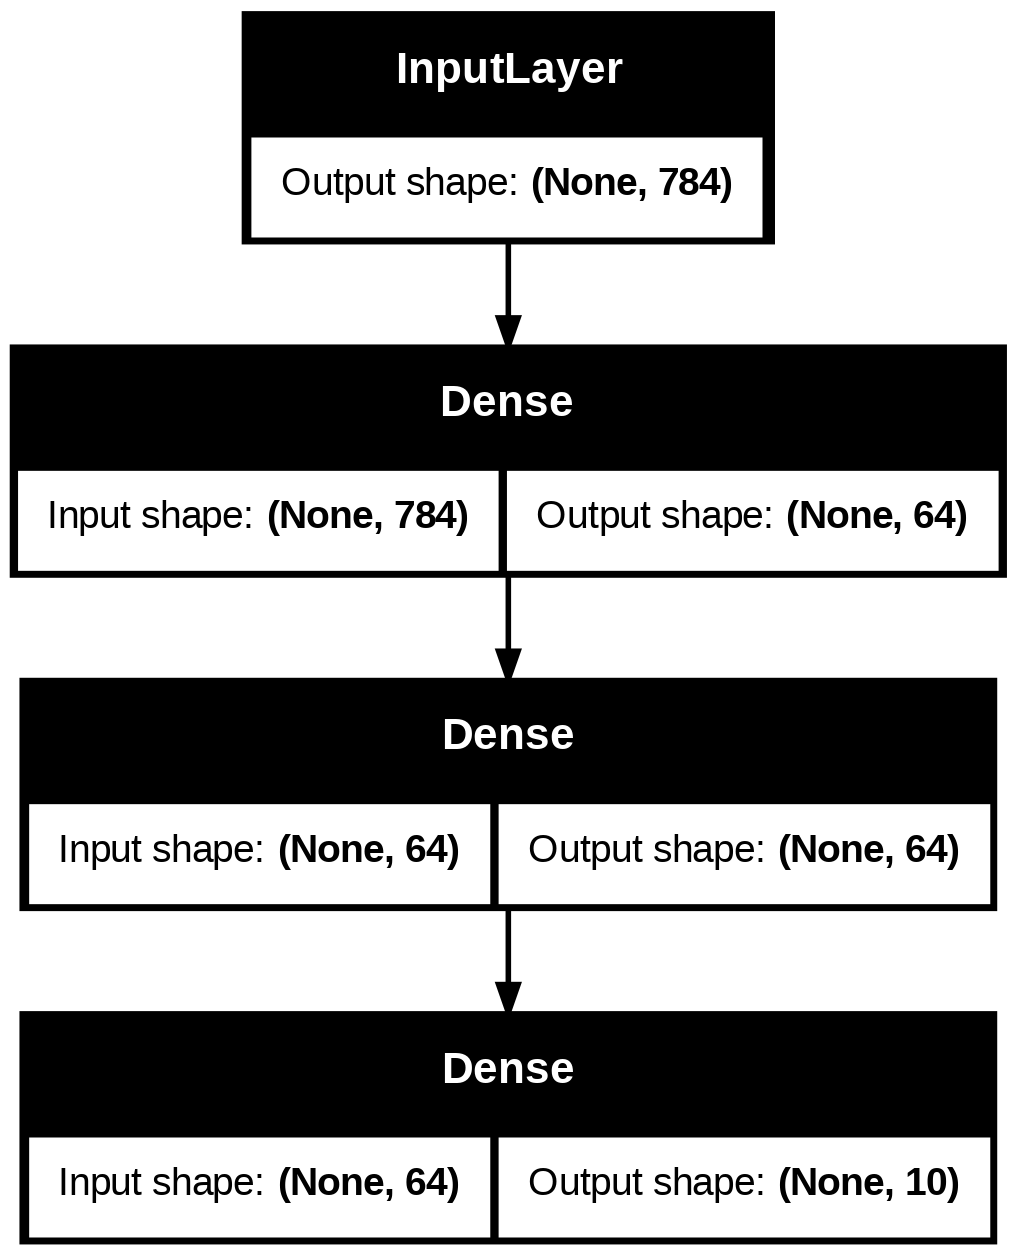

In [22]:
keras.utils.plot_model(model, "feedforward_model_with_shape_info.png", show_shapes=True)

# Load MNIST dataset

  Each single MNIST image of a handwritten digit 0, 1, 2, …, 8, 9 is encoded as a matrix of size `28*28` whose entries are 8-bit unsigned integers (i.e., each entry is an integer in the range from `0` to `2^8 - 1 = 255`).
Each integer represents the grayscale color of a pixel (0 = black, 255 = white).

For reasons of computational efficiency and numerical stability, the grayscale is rescaled to be a floating-point (decimal) number in the interval `[0, 1)`, and the 28-by-28 matrix is “flattened” to be a single (column) vector of `28*28 = 784` decimal such entries, each a `float32` (32-bit floating point number).

Since the training set consists of 60,000 such digit images, each effectively a column vector of size 784, it gives a large matrix `x_train` of size `60,000 × 784`; similarly, the test set of 10,000 images gives a `10,000 × 784` matrix `x_test`.


In [23]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.reshape(60000, 784).astype("float32") / 255
x_test = x_test.reshape(10000, 784).astype("float32") / 255

# Compile and train the model

By default, when a model is “compiled”, its parameters are initialized randomly and uniformly (with zero mean and variance determined by the input and output dimensions at each layer—but otherwise not of immediate interest to us right now).

When `model` is applied to an input of size `m × 764`, it is applied to *each* of the `m` columns, one at a time—because `model` only accepts as input a (column) vector of size 764, and outputs one of size 10;
in other words, `model` sees those `m` *rows* as completely independent of each other.
The result is a matrix of size `m × 10`.

`batch_size=64` means that each “training step” of the model uses *only* a randomly-chosen batch of (about) `m = 64` inputs (i.e., 64 rows of `x_train`) at a time, until all 60,000 rows are exhausted.
This called a (single) “epoch”, which consists of (about) `60,000/64 ≈ 934` such steps.
The process is restarted (bringing back all 60,000 rows of `x_train`) and carried out a total number of epochs `num_epochs = 20`.

(Actually, `validation_split=0.2` means that 20% of the training data is excluded during each epoch, so an epoch therefore only consists of about `0.8 * 934 ≈ 747` batches of `≈ 64` training images each.)

Keras has various built-in optimization algorithms; this model's algorithm is the *root mean-square propagation* or `RMSprop`.

The accuracy of the model is quantified using a "loss" function. A larger loss means less accuracy, so the goal as the model is trained is *reducing* or “minimizing” the loss.
(The loss function used in this implementation is called *categorical cross-entropy*. Entropy and related quantities will be introduced later in the semester.)

In [24]:
num_epochs = 20  # @param {type: "integer"}

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.RMSprop(),
    metrics=["accuracy"],
)

history = model.fit(x_train, y_train, batch_size=64, epochs=20, validation_split=0.2)

# Fix: verbose should be an integer, not a string
test_scores = model.evaluate(x_test, y_test, verbose=2)
print("Test loss:", test_scores[0])
print("Test accuracy:", test_scores[1])

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9008 - loss: 0.3480 - val_accuracy: 0.9417 - val_loss: 0.2028
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9519 - loss: 0.1629 - val_accuracy: 0.9576 - val_loss: 0.1449
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9636 - loss: 0.1221 - val_accuracy: 0.9644 - val_loss: 0.1209
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9712 - loss: 0.0965 - val_accuracy: 0.9665 - val_loss: 0.1105
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9762 - loss: 0.0805 - val_accuracy: 0.9677 - val_loss: 0.1105
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9802 - loss: 0.0667 - val_accuracy: 0.9686 - val_loss: 0.1100
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9827 - loss: 0.0570 - val_accuracy: 0.9702 - val_loss: 0.1029
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9853 - loss: 0.0490 - val_accuracy: 0.

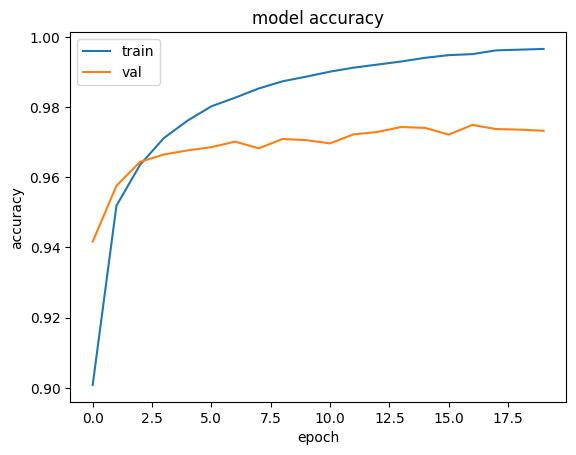

In [25]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

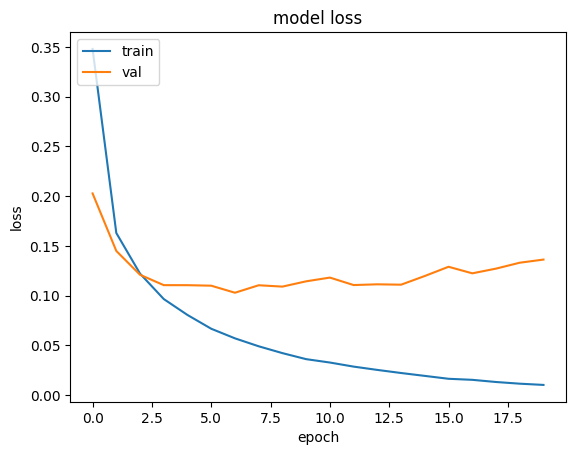

In [26]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()


The code below randomly chooses 5 of the 10,000 images in the test set and applies `model` to assign a label (0, 1, …, 9) using a straightforward likelihood maximization procedure.
Very few images in the test set should be misclassified:
the `True` and `Pred`icted labels should be in agreement.

## Hyperparameter Tuning

Let's try different combinations of hidden layer dimensions and the number of epochs to see how they impact the model's performance. We'll track the number of parameters and the test accuracy for each configuration.

In [27]:
import pandas as pd
import itertools

dim_hl_1_options = [32, 64, 128]
dim_hl_2_options = [32, 64, 128]
num_epochs_options = [10, 20, 30]

hyperparameter_combinations = []
for h1, h2, epochs in itertools.product(dim_hl_1_options, dim_hl_2_options, num_epochs_options):
    hyperparameter_combinations.append({
        'dim_hl_1': h1,
        'dim_hl_2': h2,
        'num_epochs': epochs
    })

results = []

print(f"Testing {len(hyperparameter_combinations)} combinations.")

for i, params in enumerate(hyperparameter_combinations):
    print(f"\n--- Running configuration {i+1}/{len(hyperparameter_combinations)} ---")
    print(f"Hidden Layer 1: {params['dim_hl_1']}, Hidden Layer 2: {params['dim_hl_2']}, Epochs: {params['num_epochs']}")

    inputs = keras.Input(shape=(784,))
    hidden1 = layers.Dense(params['dim_hl_1'], activation="relu")(inputs)
    hidden2 = layers.Dense(params['dim_hl_2'], activation="relu")(hidden1)
    outputs = layers.Dense(10)(hidden2)
    model = keras.Model(inputs=inputs, outputs=outputs, name=f"mnist_model_{i}")

    model.compile(
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        optimizer=keras.optimizers.RMSprop(),
        metrics=["accuracy"],
    )

    model.fit(x_train, y_train, batch_size=64, epochs=params['num_epochs'], validation_split=0.2, verbose=0)

    test_scores = model.evaluate(x_test, y_test, verbose=0)
    total_parameters = model.count_params()

    results.append({
        'dim_hl_1': params['dim_hl_1'],
        'dim_hl_2': params['dim_hl_2'],
        'num_epochs': params['num_epochs'],
        'total_parameters': total_parameters,
        'test_loss': test_scores[0],
        'test_accuracy': test_scores[1]
    })

results_df = pd.DataFrame(results)
display(results_df)


Testing 27 combinations.

--- Running configuration 1/27 ---
Hidden Layer 1: 32, Hidden Layer 2: 32, Epochs: 10

--- Running configuration 2/27 ---
Hidden Layer 1: 32, Hidden Layer 2: 32, Epochs: 20

--- Running configuration 3/27 ---
Hidden Layer 1: 32, Hidden Layer 2: 32, Epochs: 30

--- Running configuration 4/27 ---
Hidden Layer 1: 32, Hidden Layer 2: 64, Epochs: 10

--- Running configuration 5/27 ---
Hidden Layer 1: 32, Hidden Layer 2: 64, Epochs: 20

--- Running configuration 6/27 ---
Hidden Layer 1: 32, Hidden Layer 2: 64, Epochs: 30

--- Running configuration 7/27 ---
Hidden Layer 1: 32, Hidden Layer 2: 128, Epochs: 10

--- Running configuration 8/27 ---
Hidden Layer 1: 32, Hidden Layer 2: 128, Epochs: 20

--- Running configuration 9/27 ---
Hidden Layer 1: 32, Hidden Layer 2: 128, Epochs: 30

--- Running configuration 10/27 ---
Hidden Layer 1: 64, Hidden Layer 2: 32, Epochs: 10

--- Running configuration 11/27 ---
Hidden Layer 1: 64, Hidden Layer 2: 32, Epochs: 20

--- Running 

,dim_hl_1,dim_hl_2,num_epochs,total_parameters,test_loss,test_accuracy
0,32,32,10,26506,0.124627,0.9642
1,32,32,20,26506,0.133967,0.9660
2,32,32,30,26506,0.158838,0.9667
3,32,64,10,27882,0.127937,0.9650
4,32,64,20,27882,0.120423,0.9706
5,32,64,30,27882,0.161988,0.9675
6,32,128,10,30634,0.113079,0.9681
7,32,128,20,30634,0.130104,0.9714
8,32,128,30,30634,0.155027,0.9711
9,64,32,10,52650,0.105014,0.9710


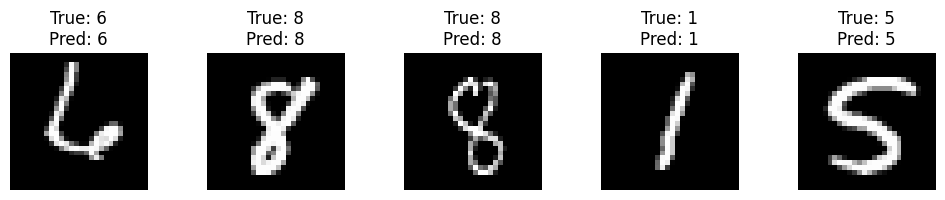

In [28]:

num_samples = 5
indices = np.random.choice(len(x_test), num_samples, replace=False)

plt.figure(figsize=(10, 2))
for i, idx in enumerate(indices):
    img = x_test[idx]
    if img.shape[-1] != 28:
        img = img.reshape(28, 28)
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    pred = model.predict(np.expand_dims(x_test[idx], axis=0), verbose=0)
    pred_label = np.argmax(pred, axis=1)[0]
    true_label = y_test[idx]
    plt.title(f"True: {true_label}\nPred: {pred_label}")
plt.tight_layout()
plt.show()